# ДЗ2. Мультимодальный адаптер к Qwen3-0.6B

**Описание задания**

В этом задании вы подключите внешнюю модальность (аудио или изображение) к языковой модели Qwen3-0.6B через небольшой обучаемый адаптер. Веса Qwen и выбранного предобученного энкодера мы замораживаем, обучается только адаптер.

Выберите один из треков:

- Трек A (аудио → текст)

Описываем аудио (AudioCaps) с помощью Qwen. Энкодер: `HuBERT` / `wav2vec2` / `Whisper Encoder`.

- Трек B (изображение → текст)

Описываем изображения (image captioning датасет) с помощью Qwen. Энкодер: любая vision-модель.

**Задачи:**

1.   Заморозить параметры `QWEN` и предобученного энкодера (аудио или vision).

2.   Создать и обучить адаптер, который сжимает временную / пространственную размерность признаков и проецирует их в скрытое пространство `Qwen`.

3.   Подготовить данные для обучения и валидации модели.

4.   Реализовать и сравнить несколько стратегий пулинга в адаптере (например, сжатие временной размерности для аудио или пространственной - для изображений).

5.   Использовать `BERTScore` для оценки качества модели на отложенном датасете.

**Основные этапы задания**

*   Подготовка данных: для "аудио → текст" загрузите датасет AudioCaps, если "изображение → текст", то загрузите датасет для image captioning (например, `Flickr8k`), обработайте данные и создайте DataLoader для батчевого обучения. Рекомендуется выполнить полную предобработку данных (прекомпьют), чтобы сократить время обработки на этапе обучения.
*   Реализация адаптера: создайте класс, который сжимает последовательность векторов.
*   Интеграция с `QWEN`: реализуйте обработку входов и передачу через `QWEN`.
*   Обучение модели: настройте процесс обучения с использованием `Cross Entropy Loss` и teacher forcing.
*   Оценка: вычислите BERTScore между сгенерированными и реальными текстами на валидационном датасете.

> **Внимание!** Последующие ячейки с условиями оформлены (название классов и переменных, инструкциии и комментарии) в ключе работы по треку А (аудио → текст). Если вы выбираете работать с vision задачей, можете ориентироваться содержательно на представленные кодовые сниппеты, но видоизменять их под свою задачу.

### Сеттинг

In [ ]:
!pip install transformers
!pip install datasets torchaudio
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig
)
from datasets import load_dataset
import random
import numpy as np
import pandas as pd
from bert_score import BERTScorer
from tqdm import tqdm


from torch.optim import Adam

from functools import partial

import librosa

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Загрузка данных**

Если вы выбираете трек с аудио, используйте датасет `AudioCaps`.

In [ ]:
import kagglehub
nickkar30_audiocaps_path = kagglehub.dataset_download('nickkar30/audiocaps')

Using Colab cache for faster access to the 'audiocaps' dataset.


In [ ]:
import os

print(os.listdir(nickkar30_audiocaps_path + '/audiocaps'))

['audiocaps_val_new.tsv', 'val_texts.json', 'audio', 'audiocaps_test_new.tsv', 'test_texts.json', 'audiocaps_val.tsv', 'audiocaps_train.tsv', 'audiocaps_test.tsv']


### Задание 1. Создание и обучение AudioConvAdapter (3 балла)

1. Загрузите модель **Qwen3-0.6B** и заморозьте её параметры.  
2. Загрузите предобученный аудио-энкодер (параметры также должны быть заморожены). Вы можете выбрать одну из следующих моделей: **HuBERT**, **wav2vec2**, или **Whisper Encoder**. Учтите особенности выбранной модели:  
   - Например, `wav2vec2-large-960h-lv60-self` использует `flash_attention`, которая работает только с GPU архитектуры Ampere и с типом данных float16. Это может вызвать сложности, если используется другое оборудование.  
3. Реализуйте класс `AudioConvAdapter`, который уменьшает размерность последовательности аудио по времени и переводит её в текстовое пространство модели QWEN.

In [ ]:
qwen_model_name = "Qwen/Qwen3-0.6B"
qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name, trust_remote_code=True)
qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_name,
    torch_dtype=torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True
)

for param in qwen_model.parameters():
    param.requires_grad = False

print(f"Qwen3-0.6B загружен, hidden_size: {qwen_model.config.hidden_size}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen3-0.6B загружен, hidden_size: 1024


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoProcessor, AutoModel

audio_model_name = "openai/whisper-small"

audio_processor = AutoProcessor.from_pretrained(audio_model_name)
audio_encoder = AutoModel.from_pretrained(audio_model_name)

# Замораживаем параметры аудио-энкодера
for param in audio_encoder.parameters():
    param.requires_grad = False

if torch.cuda.is_available():
    audio_encoder = audio_encoder.cuda()

print(f"Whisper загружен, hidden_size: {audio_encoder.config.hidden_size}")


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Whisper загружен, hidden_size: 768


In [ ]:
class AudioConvAdapter(nn.Module):
    """
    Пример максимально упрощённого адаптера из 4 блоков:
    relu(Conv1D(in, in)) -> Linear(in, hid) -> relu(Conv1D(hid, hid)) -> Linear(hid, qwen_in)
    где in - размер аудио вектора
    hid - скрытое состояние адаптера (hid > in)
    qwen_in - размерность хиддена qwen
      - первый Conv1D уменьшает число временных шагов (stride/pooling),
      - затем Linear преобразует hidden_dim,
      - потом снова Conv1D (доп. pooling),
      - потом Linear подгоняет к нужной размерности.
    Можно без линейных слоев увеличивать размерность, но получится больше параметров
    """

    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        hidden_dim: int = 1024,
        kernel_size: int = 3,
        stride: int = 2,
        dropout: float = 0.1,
        pooling_method: str = "conv",  # "conv", "attention", "max", "avg"
    ):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.pooling_method = pooling_method

        # Блок 1: Уменьшение временной размерности и преобразование размерности
        self.conv1 = nn.Conv1d(
            in_channels=input_dim,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=kernel_size//2
        )

        # Attention pooling (альтернатива conv pooling)
        if pooling_method == "attention":
            self.attention_pool = nn.MultiheadAttention(
                embed_dim=hidden_dim,
                num_heads=4,
                dropout=dropout,
                batch_first=True
            )
            self.attention_query = nn.Parameter(torch.randn(1, 1, hidden_dim))

        # Линейный слой для изменения размерности
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)

        # Блок 2: Дополнительное сжатие
        self.conv2 = nn.Conv1d(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=kernel_size//2
        )

        # Финальный линейный слой для преобразования в output_dim
        self.linear2 = nn.Linear(hidden_dim, output_dim)

        # Нормализация и dropout
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов"""
        for module in [self.conv1, self.conv2, self.linear1, self.linear2]:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Conv1d):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def apply_pooling(self, x, method):
        """Применение различных методов пулинга"""
        batch_size, seq_len, hidden_dim = x.shape

        if method == "max":
            # Max pooling по временной оси
            x_pooled, _ = torch.max(x, dim=1, keepdim=True)
            return x_pooled

        elif method == "avg":
            # Average pooling по временной оси
            x_pooled = torch.mean(x, dim=1, keepdim=True)
            return x_pooled

        elif method == "attention":
            # Attention pooling
            query = self.attention_query.expand(batch_size, -1, -1)
            x_pooled, _ = self.attention_pool(query, x, x)
            return x_pooled

        else:  # "conv" - по умолчанию
            # Conv уже применяется в forward
            return x

    def forward(self, x):
        """
        x: тензор формы [batch_size, seq_len, input_dim]
        возвращает: тензор формы [batch_size, new_seq_len, output_dim]
        """
        # Приводим к float32 если нужно
        if x.dtype != torch.float32:
            x = x.to(torch.float32)

        batch_size, seq_len, input_dim = x.shape

        # Перестановка для Conv1d: [batch, seq_len, features] -> [batch, features, seq_len]
        x = x.transpose(1, 2)

        # Блок 1: Conv1D + ReLU
        x = self.conv1(x)
        x = F.relu(x)

        # Перестановка обратно: [batch, features, seq_len] -> [batch, seq_len, features]
        x = x.transpose(1, 2)

        # Применяем выбранный метод пулинга
        if self.pooling_method != "conv":
            x = self.apply_pooling(x, self.pooling_method)

        # Линейный слой 1
        x = self.linear1(x)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Блок 2: Conv1D + ReLU (если еще осталась временная размерность)
        if x.shape[1] > 1:  # Если есть временная размерность
            x = x.transpose(1, 2)
            x = self.conv2(x)
            x = F.relu(x)
            x = x.transpose(1, 2)

        # Применяем финальный pooling если нужно
        if self.pooling_method != "conv" and x.shape[1] > 1:
            x = self.apply_pooling(x, self.pooling_method)

        # Линейный слой 2
        x = self.linear2(x)
        x = self.norm2(x)

        return x

In [ ]:
qwen_hidden_size = qwen_model.config.hidden_size

print(qwen_hidden_size)
print(audio_encoder.config.hidden_size)

1024
768


In [ ]:
adapter_hidden_dim = 1024
audio_adapter = AudioConvAdapter(
        input_dim=audio_encoder.config.hidden_size,
        output_dim=qwen_hidden_size,
        hidden_dim=adapter_hidden_dim,
        dropout=0.1
    ).to(device)

print("Trainable parameters in adapter:", sum(p.numel() for p in audio_adapter.parameters() if p.requires_grad))

Trainable parameters in adapter: 7610368


### Задание 2. Подготовка данных (2 балла)

In [ ]:
os.listdir(nickkar30_audiocaps_path + '/audiocaps')

['audiocaps_val_new.tsv',
 'val_texts.json',
 'audio',
 'audiocaps_test_new.tsv',
 'test_texts.json',
 'audiocaps_val.tsv',
 'audiocaps_train.tsv',
 'audiocaps_test.tsv']

In [ ]:
os.listdir('/kaggle/input/audiocaps/audiocaps')

['audiocaps_val_new.tsv',
 'val_texts.json',
 'audio',
 'audiocaps_test_new.tsv',
 'test_texts.json',
 'audiocaps_val.tsv',
 'audiocaps_train.tsv',
 'audiocaps_test.tsv']

In [ ]:
def fix_tsv_file(tsv_in, tsv_out):
    with open(tsv_in, "r", encoding="utf-8") as fin, open(tsv_out, "w", encoding="utf-8") as fout:
        for line in fin:
            parts = line.split("\t")
            if len(parts) > 4:
                fixed_line = "\t".join(parts[:3]) + "\t" + " ".join(parts[3:]).strip()
                fout.write(fixed_line + "\n")
            else:
                fout.write(line)

fix_tsv_file(nickkar30_audiocaps_path + '/audiocaps/' + "audiocaps_train.tsv",
             '/kaggle/' + "audiocaps_train_fixed.tsv")

In [ ]:
os.listdir('/kaggle')

['audiocaps_train_fixed.tsv', 'input']

In [ ]:
nickkar30_audiocaps_path

'/kaggle/input/audiocaps'

In [ ]:
class AudioCapsDataset(Dataset):
    def __init__(
        self,
        tsv_path: str,
        root_dir: str,
        audio_processor=None,
        max_audio_length: int = 16000 * 10,
        target_sample_rate: int = 16000,
    ):
        super().__init__()
        self.df = pd.read_csv(tsv_path, sep="\t")
        self.root_dir = root_dir
        self.max_audio_length = max_audio_length
        self.target_sample_rate = target_sample_rate
        self.audio_processor = audio_processor

        print(f"Загружено {len(self.df)} записей")
        print(f"Audio processor: {'загружен' if audio_processor else 'None'}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """Получение одного примера данных"""
        caption = self.df.iloc[idx]['text']
        audio_rel_path = self.df.iloc[idx]['audio']
        audio_path = os.path.join(self.root_dir, audio_rel_path)

        try:
            # Загружаем аудио
            waveform, sr = librosa.load(
                audio_path,
                sr=self.target_sample_rate,
                duration=self.max_audio_length / self.target_sample_rate
            )

            # Обрезаем/дополняем
            target_length = self.max_audio_length
            if len(waveform) > target_length:
                waveform = waveform[:target_length]
            elif len(waveform) < target_length:
                padding = target_length - len(waveform)
                waveform = np.pad(waveform, (0, padding), mode='constant')

            # Нормализуем
            if np.max(np.abs(waveform)) > 0:
                waveform = waveform / np.max(np.abs(waveform))

            # Обрабатываем через processor
            inputs = self.audio_processor(
                waveform,
                sampling_rate=sr,
                return_tensors="pt",
                padding=True
            )
            return inputs, caption  # ВАЖНО: возвращаем 2 элемента!

        except Exception as e:
            print(f"Ошибка при загрузке аудио {audio_path}: {e}")
            waveform = np.zeros(self.max_audio_length, dtype=np.float32)
            if self.audio_processor is not None:
                inputs = self.audio_processor(
                    waveform,
                    sampling_rate=self.target_sample_rate,
                    return_tensors="pt",
                    padding=True
                )
                return inputs, caption
            else:
                return waveform, self.target_sample_rate, caption


# Collate функция для WhisperProcessor с правильным паддингом
def collate_fn_whisper(batch):
    """
    batch: список из N элементов [(waveform_i, sr_i, caption_i), ...].
    Делает единый вызов audio_processor с правильным паддингом для Whisper.
    """
    waveforms = []
    captions = []

    for waveform, sr, caption in batch:
        waveforms.append(waveform)
        captions.append(caption)

    # Whisper требует фиксированную длину 3000 кадров
    # Преобразуем waveforms в mel-спектрограммы с правильным паддингом
    audio_inputs = audio_processor(
        waveforms,
        sampling_rate=16000,
        padding="max_length",  # Важно: паддинг до максимальной длины
        max_length=3000,       # Whisper ожидает 3000 кадров
        truncation=True,       # Обрезаем если длиннее
        return_tensors="pt"
    )

    return audio_inputs, captions

In [ ]:
train_tsv = '/kaggle/' + 'audiocaps_train_fixed.tsv'
val_tsv   = '/kaggle/input' + '/audiocaps/audiocaps/' + "audiocaps_val_new.tsv"

root_dir = '/kaggle/input' + '/audiocaps/'

print("Проверка файлов...")
print(f"train_tsv: {train_tsv} - {'✅ Существует' if os.path.exists(train_tsv) else '❌ Не найден'}")
print(f"val_tsv: {val_tsv} - {'✅ Существует' if os.path.exists(val_tsv) else '❌ Не найден'}")
print(f"root_dir: {root_dir} - {'✅ Существует' if os.path.exists(root_dir) else '❌ Не найден'}")

# Создаем аудио процессор для Whisper
print("\nЗагрузка аудио процессора...")
try:
    from transformers import WhisperProcessor
    audio_processor = WhisperProcessor.from_pretrained("openai/whisper-small")
    print("✅ Whisper processor загружен")

except Exception as e:
    print(f"Ошибка при загрузке Whisper processor: {e}")
    print("Используем AutoProcessor...")
    from transformers import AutoProcessor
    audio_processor = AutoProcessor.from_pretrained("openai/whisper-small")
    print("✅ Whisper processor загружен через AutoProcessor")

# Создаем датасеты
print("\nСоздание датасетов...")
train_dataset = AudioCapsDataset(
    tsv_path=train_tsv,
    root_dir=root_dir,
    audio_processor=audio_processor,  # Используем Whisper processor
    max_audio_length=16000 * 10,  # 10 секунд
    target_sample_rate=16000,
)

val_dataset = AudioCapsDataset(
    tsv_path=val_tsv,
    root_dir=root_dir,
    audio_processor=audio_processor,
    max_audio_length=16000 * 10,
    target_sample_rate=16000,
)

print(f"Размер train датасета: {len(train_dataset)}")
print(f"Размер val датасета: {len(val_dataset)}")

Проверка файлов...
train_tsv: /kaggle/audiocaps_train_fixed.tsv - ✅ Существует
val_tsv: /kaggle/input/audiocaps/audiocaps/audiocaps_val_new.tsv - ✅ Существует
root_dir: /kaggle/input/audiocaps/ - ✅ Существует

Загрузка аудио процессора...
✅ Whisper processor загружен

Создание датасетов...
Загружено 49490 записей
Audio processor: загружен
Загружено 495 записей
Audio processor: загружен
Размер train датасета: 49490
Размер val датасета: 495


In [ ]:
class AudioCapsDataset(Dataset):
    def __init__(
        self,
        tsv_path: str,
        root_dir: str,
        max_audio_length: int = 16000 * 10,  # 10 секунд при 16kHz
        target_sample_rate: int = 16000,
    ):
        super().__init__()
        self.df = pd.read_csv(tsv_path, sep="\t")
        self.root_dir = root_dir
        self.max_audio_length = max_audio_length
        self.target_sample_rate = target_sample_rate

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """Получение одного примера данных"""
        caption = self.df.iloc[idx]['text']
        audio_rel_path = self.df.iloc[idx]['audio']
        audio_path = os.path.join(self.root_dir, audio_rel_path)

        try:
            # Загружаем аудио
            waveform, sr = librosa.load(
                audio_path,
                sr=self.target_sample_rate,
                duration=self.max_audio_length / self.target_sample_rate
            )

            # Обрезаем/дополняем
            target_length = self.max_audio_length
            if len(waveform) > target_length:
                waveform = waveform[:target_length]
            elif len(waveform) < target_length:
                padding = target_length - len(waveform)
                waveform = np.pad(waveform, (0, padding), mode='constant')

            # Нормализуем
            if np.max(np.abs(waveform)) > 0:
                waveform = waveform / np.max(np.abs(waveform))

            return waveform, sr, caption

        except Exception as e:
            print(f"Ошибка при загрузке аудио {audio_path}: {e}")
            waveform = np.zeros(self.max_audio_length, dtype=np.float32)
            return waveform, self.target_sample_rate, caption

def collate_fn_whisper_fixed(batch, audio_processor, target_length=3000):
    """
    Collate функция с фиксированной длиной для Whisper.
    Whisper требует mel-спектрограммы длиной 3000 кадров.
    """
    batch_features = []
    captions = []

    for waveform, sr, caption in batch:
        # Преобразуем каждый waveform отдельно
        features = audio_processor(
            waveform,
            sampling_rate=sr,
            return_tensors="pt"
        ).input_features

        # features shape: [1, 80, time_frames]
        time_frames = features.shape[2]

        # Паддинг/обрезание до target_length (3000 для Whisper)
        if time_frames < target_length:
            # Паддинг справа
            pad_amount = target_length - time_frames
            padded_features = F.pad(features, (0, pad_amount), mode='constant', value=0)
        elif time_frames > target_length:
            # Обрезаем
            padded_features = features[:, :, :target_length]
        else:
            padded_features = features

        batch_features.append(padded_features)
        captions.append(caption)

    # Собираем батч
    batch_inputs = {
        "input_features": torch.cat(batch_features, dim=0),  # [B, 80, 3000]
        "attention_mask": torch.ones(len(batch_features), target_length, dtype=torch.float32)
    }

    return batch_inputs, captions

In [ ]:
train_tsv = '/kaggle/' + 'audiocaps_train_fixed.tsv'
val_tsv   = '/kaggle/input' + '/audiocaps/audiocaps/' + "audiocaps_val_new.tsv"
root_dir = '/kaggle/input' + '/audiocaps/'

# Загрузка WhisperProcessor
print("Загрузка WhisperProcessor...")
from transformers import WhisperProcessor
audio_processor = WhisperProcessor.from_pretrained("openai/whisper-small")
print("✅ WhisperProcessor загружен")

# Тестируем преобразование одного файла
test_waveform = torch.randn(16000)  # 1 секунда аудио
test_features = audio_processor(
    test_waveform,
    sampling_rate=16000,
    return_tensors="pt"
)

# Создаем датасеты
print("\nСоздание датасетов...")
train_dataset = AudioCapsDataset(
    tsv_path=train_tsv,
    root_dir=root_dir,
    max_audio_length=16000 * 10,
    target_sample_rate=16000,
)

val_dataset = AudioCapsDataset(
    tsv_path=val_tsv,
    root_dir=root_dir,
    max_audio_length=16000 * 10,
    target_sample_rate=16000,
)

print(f"Размер train датасета: {len(train_dataset)}")
print(f"Размер val датасета: {len(val_dataset)}")

# Создаем collate функцию
collate_fn = partial(collate_fn_whisper_fixed,
                    audio_processor=audio_processor,
                    target_length=3000)

# Создаем DataLoader'ы
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
)

Загрузка WhisperProcessor...
✅ WhisperProcessor загружен

Создание датасетов...
Размер train датасета: 49490
Размер val датасета: 495


In [ ]:
for batch in train_loader:
    audio_inputs, captions = batch

    # Проверяем размерности
    batch_size, num_mels, time_frames = audio_inputs["input_features"].shape
    assert num_mels == 80, f"Ожидается 80 mel-каналов, получено {num_mels}"
    assert time_frames == 3000, f"Ожидается 3000 time frames, получено {time_frames}"


    print(f"\nПервые 2 captions: {captions[:2]}")

    break

for batch in val_loader:
    audio_inputs, captions = batch

    print(f"input_features.shape = {audio_inputs['input_features'].shape}")
    print(f"attention_mask.shape = {audio_inputs['attention_mask'].shape}")

    batch_size, num_mels, time_frames = audio_inputs["input_features"].shape
    print(f"✅ Batch size: {batch_size}, Mel bands: {num_mels}, Time frames: {time_frames}")

    break

for batch in train_loader:
    audio_inputs, captions = batch
    print("input_features.shape =", audio_inputs["input_features"].shape)
    print("attention_mask.shape =", audio_inputs["attention_mask"].shape)
    print("captions =", captions)
    break



Первые 2 captions: ['The engine of a vehicle is trying to start', 'A person laughs loudly while dogs bark']
input_features.shape = torch.Size([4, 80, 3000])
attention_mask.shape = torch.Size([4, 3000])
✅ Batch size: 4, Mel bands: 80, Time frames: 3000
input_features.shape = torch.Size([4, 80, 3000])
attention_mask.shape = torch.Size([4, 3000])
captions = ['Humming followed by two loud buzzes', 'Ducks are quacking as a stream of water gurgles, and a man speaks', 'A loud engine idles and then turns off', 'A vehicle engine sputters and travels down a wet road and there is a bang in the distance']


## Задание 3. Трейн QwenAudioDescription (3 балла)


1. Напишите класс `QwenAudioDescriptionTrainer`, который будет включать в себя:
   - Обучение адаптера (`train_one_epoch`).
   - Валидацию (`validate`).
   - Генерацию описания аудио (`generate`).
2. Реализуйте процесс обучения, который объединяет аудио-эмбеддинги и текстовые токены, а затем передаёт их в QWEN для предсказания текстов.
3. Используйте Cross Entropy Loss для оптимизации аудио-адаптера. Остальные параметры модели остаются замороженными.


In [ ]:
# Создаем ID для специального токена [AUDIO]
if "[AUDIO]" not in qwen_tokenizer.get_vocab():
    qwen_tokenizer.add_tokens(["[AUDIO]"])

audio_token_id = qwen_tokenizer.convert_tokens_to_ids("[AUDIO]")
special_token_id = audio_token_id
print(f"Audio token ID: {audio_token_id}")

# Обновляем модель с новым размером словаря
qwen_model.resize_token_embeddings(len(qwen_tokenizer))

Audio token ID: 151669


Embedding(151670, 1024)

In [ ]:
class QwenAudioDescriptionTrainer:
    def __init__(self, qwen_model, qwen_tokenizer, audio_encoder, audio_adapter, device, lr=1e-4):
        self.qwen_model = qwen_model
        self.qwen_tokenizer = qwen_tokenizer
        self.audio_encoder = audio_encoder
        self.audio_adapter = audio_adapter
        self.device = device

        # Убедимся что все модели на правильном device
        self.qwen_model = self.qwen_model.to(self.device)
        self.audio_encoder = self.audio_encoder.to(self.device)
        self.audio_adapter = self.audio_adapter.to(self.device)

        # Замораживаем все модели кроме адаптера
        for param in self.qwen_model.parameters():
            param.requires_grad = False

        for param in self.audio_encoder.parameters():
            param.requires_grad = False

        # Оптимизатор Adam (только для audio_adapter)
        self.optimizer = Adam(self.audio_adapter.parameters(), lr=lr)

        print(f"Trainer инициализирован:")
        print(f"  Audio token ID: {audio_token_id}")
        print(f"  Learning rate: {lr}")
        print(f"  Device: {device}")

    def prepare_audio_embeddings(self, audio_inputs):
        """Подготовка аудио эмбеддингов - используем только encoder часть Whisper"""
        # Получаем input_features и attention_mask
        input_features = audio_inputs["input_features"].to(self.device)
        attention_mask = audio_inputs.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(self.device)

        # Whisper - encoder-decoder модель, но нам нужен только encoder
        # Используем метод encoder напрямую
        with torch.no_grad():
            # Получаем encoder outputs
            encoder_outputs = self.audio_encoder.encoder(
                input_features=input_features,
                attention_mask=attention_mask
            )
            audio_hidden_states = encoder_outputs.last_hidden_state

        # Пропускаем через аудио-адаптер
        audio_embeds = self.audio_adapter(audio_hidden_states)

        # Если адаптер вернул последовательность, усредняем
        if audio_embeds.dim() == 3 and audio_embeds.shape[1] > 1:
            audio_embeds = torch.mean(audio_embeds, dim=1, keepdim=True)

        return audio_embeds

    def train_one_epoch(self, train_loader):
        self.audio_adapter.train()
        total_loss = 0.0
        processed_batches = 0

        for batch_idx, batch in enumerate(tqdm(train_loader, desc="Training")):
            audio_inputs, texts = batch

            print(f"\nBatch {batch_idx}:")

            try:
                # Подготовка аудио эмбеддингов
                audio_embeds = self.prepare_audio_embeddings(audio_inputs)

                # Токенизируем тексты
                text_tokens = self.qwen_tokenizer(
                    texts,
                    padding=True,
                    truncation=True,
                    max_length=64,
                    return_tensors="pt"
                )
                input_ids = text_tokens["input_ids"].to(self.device)
                attention_mask = text_tokens["attention_mask"].to(self.device)

                # Получаем текстовые эмбеддинги
                text_embeds = self.qwen_model.get_input_embeddings()(input_ids)

                # Конкатенируем аудио и текстовые эмбеддинги
                combined_embeds = torch.cat([audio_embeds, text_embeds], dim=1)

                # Расширяем attention_mask для аудио токена
                batch_size = audio_embeds.shape[0]
                audio_attention = torch.ones(batch_size, 1, device=self.device)
                combined_attention = torch.cat([audio_attention, attention_mask], dim=1)

                # Создаем labels (игнорируем аудио токен)
                labels = torch.cat([
                    torch.full((batch_size, 1), -100, device=self.device),
                    input_ids
                ], dim=1)

                # Qwen - causal LM

                text_embeds = text_embeds.to(torch.float32)

                outputs = self.qwen_model(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    labels=labels
                )

                loss = outputs.loss
                print(f"  Loss: {loss.item():.4f}")

                # Оптимизация
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.audio_adapter.parameters(), max_norm=1.0)
                self.optimizer.step()

                total_loss += loss.item()
                processed_batches += 1

            except Exception as e:
                print(f"❌ Ошибка в batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()
                continue

        avg_loss = total_loss / processed_batches if processed_batches > 0 else 0
        print(f"\nProcessed {processed_batches} batches, avg loss: {avg_loss:.4f}")
        return avg_loss

    def validate(self, val_loader):
        self.audio_adapter.eval()
        val_loss = 0.0
        processed_batches = 0

        with torch.no_grad():
            for batch_idx, batch in enumerate(tqdm(val_loader, desc="Validating")):
                audio_inputs, texts = batch

                try:
                    # Аналогично train, но без backward
                    audio_embeds = self.prepare_audio_embeddings(audio_inputs)

                    text_tokens = self.qwen_tokenizer(
                        texts,
                        padding=True,
                        truncation=True,
                        max_length=64,
                        return_tensors="pt"
                    )
                    input_ids = text_tokens["input_ids"].to(self.device)
                    attention_mask = text_tokens["attention_mask"].to(self.device)

                    text_embeds = self.qwen_model.get_input_embeddings()(input_ids)
                    combined_embeds = torch.cat([audio_embeds, text_embeds], dim=1)

                    batch_size = audio_embeds.shape[0]
                    audio_attention = torch.ones(batch_size, 1, device=self.device)
                    combined_attention = torch.cat([audio_attention, attention_mask], dim=1)

                    labels = torch.cat([
                        torch.full((batch_size, 1), -100, device=self.device),
                        input_ids
                    ], dim=1)

                    outputs = self.qwen_model(
                        inputs_embeds=combined_embeds,
                        attention_mask=combined_attention,
                        labels=labels
                    )

                    val_loss += outputs.loss.item()
                    processed_batches += 1

                except Exception as e:
                    print(f"❌ Ошибка в валидационном batch {batch_idx}: {e}")
                    continue

        return val_loss / processed_batches if processed_batches > 0 else 0

    def generate(self, audio_inputs, max_length=50, temperature=0.7):
        """
        Генерация описания для одного аудио.
        """
        self.audio_adapter.eval()
        with torch.no_grad():
            # Подготовка аудио эмбеддингов
            audio_embeds = self.prepare_audio_embeddings(audio_inputs)
            batch_size = audio_embeds.shape[0]

            # Создаем промпт
            prompt = "[AUDIO] Describe the audio:"
            prompt_tokens = self.qwen_tokenizer(
                prompt,
                return_tensors="pt",
                padding=True
            ).to(self.device)

            # Повторяем для batch_size
            prompt_input_ids = prompt_tokens.input_ids.repeat(batch_size, 1)
            prompt_attention_mask = prompt_tokens.attention_mask.repeat(batch_size, 1)

            # Получаем эмбеддинги промпта
            prompt_embeds = self.qwen_model.get_input_embeddings()(prompt_input_ids)

            # Заменяем [AUDIO] токен на аудио эмбеддинги
            audio_token_pos = (prompt_input_ids[0] == audio_token_id).nonzero()
            if len(audio_token_pos) > 0:
                pos = audio_token_pos[0].item()
                for i in range(batch_size):
                    prompt_embeds[i, pos] = audio_embeds[i, 0]

            # Генерация текста
            generated_ids = self.qwen_model.generate(
                inputs_embeds=prompt_embeds,
                attention_mask=prompt_attention_mask,
                max_length=max_length,
                temperature=temperature,
                do_sample=True if temperature > 0 else False,
                pad_token_id=self.qwen_tokenizer.pad_token_id,
                eos_token_id=self.qwen_tokenizer.eos_token_id
            )

            # Декодируем
            generated_texts = []
            for i, gen_ids in enumerate(generated_ids):
                text = self.qwen_tokenizer.decode(gen_ids, skip_special_tokens=True)
                if text.startswith(prompt):
                    text = text[len(prompt):].strip()
                generated_texts.append(text)

        return generated_texts if batch_size > 1 else generated_texts[0]

> Убедиться, что:
>
> При обучении лосс падает.
>
> При валидации всё аналогично, только без backward.
>
>  При генерации появляется текст (возможно, не самый качественный - это зависит от данных и количества эпох).

In [ ]:
trainer = QwenAudioDescriptionTrainer(
    qwen_model=qwen_model,
    qwen_tokenizer=qwen_tokenizer,
    audio_encoder=audio_encoder,
    audio_adapter=audio_adapter,
    device=device,
    lr=1e-4
)


test_loader = []
for i, batch in enumerate(train_loader):
    test_loader.append(batch)
    if i >= 999:  # берём только 1000 батчей, чтоб не ждать фулл прогон эпохи (Альбина написала, что можно так)
        break

train_loss = trainer.train_one_epoch(test_loader)

# Тестируем генерацию
print("\nТестируем генерацию...")
for batch in val_loader:
    audio_inputs, texts = batch
    test_audio = {}
    for key in audio_inputs:
        if torch.is_tensor(audio_inputs[key]):
            test_audio[key] = audio_inputs[key][0:1]

    generated = trainer.generate(test_audio, max_length=30)
    print(f"✅ Сгенерировано: {generated}")
    print(f"✅ Ground truth: {texts[0]}")
    break

Trainer инициализирован:
  Audio token ID: 151669
  Learning rate: 0.0001
  Device: cuda


Training:   0%|          | 0/1000 [00:00<?, ?it/s]


Batch 0:


Training:   0%|          | 1/1000 [00:00<12:55,  1.29it/s]

  Loss: 3.6711

Batch 1:


...

Training: 100%|█████████▉| 999/1000 [10:31<00:00,  1.61it/s]

  Loss: 3.8185

Batch 999:


Training: 100%|██████████| 1000/1000 [10:32<00:00,  1.58it/s]

  Loss: 4.0409

Processed 1000 batches, avg loss: 3.8294

Тестируем генерацию...


✅ Сгенерировано:  A man is speaking, and the woman is listening, and the man is talking about his job, and the woman is listening
✅ Ground truth: Rustling occurs, ducks quack and water splashes, followed by an adult female and adult male speaking and duck calls being blown


Вроде работает, что-то внятное правдоподобное генерится, но пока не супер качественно (правильно нашёл мужчину и женщину, но вот про утку ничего не сгенерилось)



Тренироваться на несколько эпох запустим уже в следующем пункте

Спойлер, чтобы результаты уже были для этого пункта задания: вот так там получилось на 30 эпохах и небольшом числе батчей (16 на трэйн и 4 на вал):

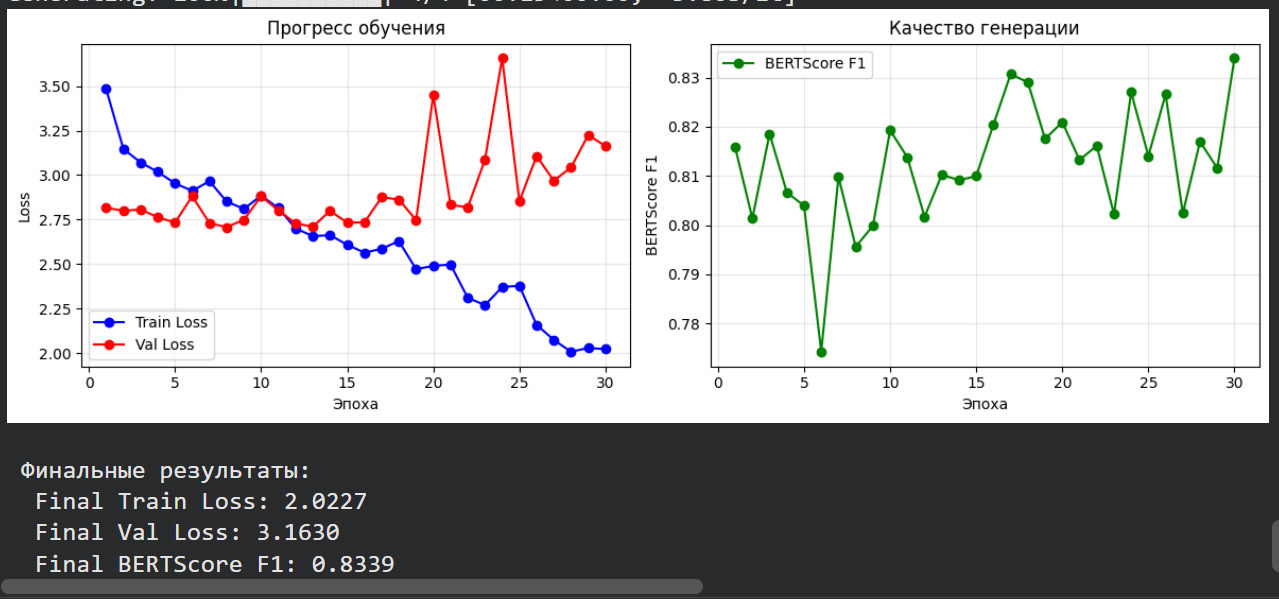

## Задание 4. Валидация (2 балла)

1. Используйте валидационный набор данных, чтобы проверить, насколько хорошо модель генерирует текстовые описания для аудио/картинок.

2. Реализуйте процесс генерации текстов для всех аудио/картинок из валидационного набора.

3. Используйте метрику **BERTScore** для оценки качества сгенерированных описаний.

4. Отобразите примеры сгенерированных текстов и сравните их с истинными описаниями (references).

In [ ]:
!pip install bert-score

In [ ]:
from bert_score import BERTScorer
import matplotlib.pyplot as plt

class AudioDescriptionEvaluator:
    def __init__(self, trainer, device):
        self.trainer = trainer
        self.device = device
        self.scorer = BERTScorer(lang="en", device=device)

    def evaluate_val_set(self, val_loader, num_samples=None):
        """Оценка на валидационном наборе данных"""
        self.trainer.audio_adapter.eval()

        all_generated_texts = []
        all_reference_texts = []

        print(f"\nГенерация текстов для валидационного набора...")

        with torch.no_grad():
            for i, batch in enumerate(tqdm(val_loader, desc="Generating")):
                if num_samples and i * len(batch[1]) >= num_samples:
                    break

                audio_inputs, texts = batch

                # Генерируем описания для всего батча
                generated_texts = self.trainer.generate(audio_inputs, max_length=50, temperature=0.7)

                # Если generate возвращает строку для одного элемента
                if isinstance(generated_texts, str):
                    generated_texts = [generated_texts]

                all_generated_texts.extend(generated_texts)
                all_reference_texts.extend(texts)


        # Ограничиваем количество, если нужно для тестирования
        if num_samples and len(all_generated_texts) > num_samples:
            all_generated_texts = all_generated_texts[:num_samples]
            all_reference_texts = all_reference_texts[:num_samples]


        # Вычисляем BERTScore
        P, R, F1 = self.scorer.score(all_generated_texts, all_reference_texts)

        # Конвертируем в numpy для удобства
        P = P.cpu().numpy()
        R = R.cpu().numpy()
        F1 = F1.cpu().numpy()

        return {
            'generated_texts': all_generated_texts,
            'reference_texts': all_reference_texts,
            'precision': P,
            'recall': R,
            'f1': F1,
            'precision_mean': np.mean(P),
            'recall_mean': np.mean(R),
            'f1_mean': np.mean(F1)
        }

    def print_evaluation_results(self, results):
        """Вывод результатов оценки"""

        f1_scores = results['f1']
        best_idx = np.argmax(f1_scores)

        print(f"\nЛучший (F1={f1_scores[best_idx]:.4f}):")
        print(f"  Сгенерировано: {results['generated_texts'][best_idx]}")
        print(f"  Референс: {results['reference_texts'][best_idx]}")


        # Гистограмма распределения F1 scores
        plt.figure(figsize=(10, 6))
        plt.hist(f1_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(x=results['f1_mean'], color='red', linestyle='--', label=f'Среднее: {results["f1_mean"]:.4f}')
        plt.xlabel('BERTScore F1')
        plt.ylabel('Количество примеров')
        plt.title('Распределение BERTScore F1')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        return results

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Генерация текстов для валидационного набора...


Generating: 100%|██████████| 124/124 [05:31<00:00,  2.68s/it]



Лучший (F1=0.8756):
  Сгенерировано:  a girl wearing a pink dress, dancing with a boy in a pink dress, holding hands, smiling. Then she sings a song in a soft voice with a soft melody, then the boy plays a guitar and sings a song
  Референс: A woman talks while a baby cries and a man whispers


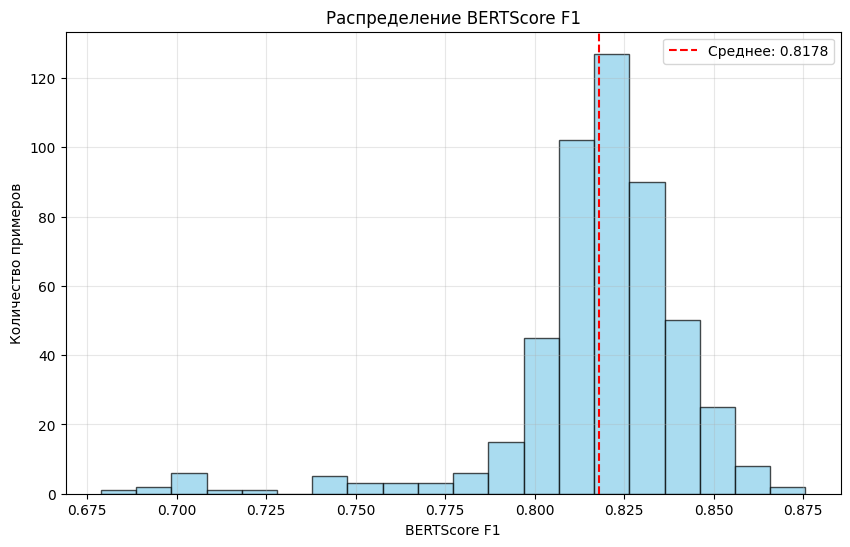

In [ ]:
evaluator = AudioDescriptionEvaluator(trainer, device)

results = evaluator.evaluate_val_set(val_loader)

eval_res = evaluator.print_evaluation_results(results)

In [ ]:
def train_and_evaluate(trainer, evaluator, train_loader, val_loader, num_epochs=10):
    """Функция для обучения и оценки модели"""
    print(f"\n{'='*60}")
    print(f"Обучение на {num_epochs} эпох")
    print(f"{'='*60}")

    train_losses = []
    val_losses = []
    bert_scores = []

    for epoch in range(num_epochs):
        print(f"\nЭпоха {epoch+1}/{num_epochs}")

        # Обучение
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)
        #print(f"Train Loss: {train_loss:.4f}")

        # Валидация по loss
        val_loss = trainer.validate(val_loader)
        val_losses.append(val_loss)
        #print(f"Val Loss: {val_loss:.4f}")

        # Оценка с BERTScore
        results = evaluator.evaluate_val_set(val_loader)
        bert_scores.append(results['f1_mean'])
        #print(f"BERTScore F1: {results['f1_mean']:.4f}")

        # Примеры генерации
        #print("\nПримеры генерации после эпохи:")
        #for batch in val_loader:
         #   audio_inputs, texts = batch
          #  test_audio = {}
           # for key in audio_inputs:
            #    if torch.is_tensor(audio_inputs[key]):
             #       test_audio[key] = audio_inputs[key][0:1]

            #generated = trainer.generate(test_audio, max_length=30)
            #print(f"  Сгенерировано: {generated}")
            #print(f"  Референс: {texts[0][:50]}...")
            #break


    # Визуализация прогресса обучения
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), train_losses, 'b-o', label='Train Loss')
    plt.plot(range(1, num_epochs+1), val_losses, 'r-o', label='Val Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title('Прогресс обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), bert_scores, 'g-o', label='BERTScore F1')
    plt.xlabel('Эпоха')
    plt.ylabel('BERTScore F1')
    plt.title('Качество генерации')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'bert_scores': bert_scores,
        'final_results': results
    }

In [ ]:
# Ограничиваем датасеты для более быстрого прогона эпох (в чате Альбина подтвердила, что так можно)
small_train = []
small_val = []

for i, batch in enumerate(train_loader):
    small_train.append(batch)
    if i >= 999:  # 1000 батчей для обучения
        break

for i, batch in enumerate(val_loader):
    small_val.append(batch)
    if i >= 9:  # 10 батчей для валидации
        break

Trainer инициализирован:
  Audio token ID: 151669
  Learning rate: 0.0001
  Device: cuda


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Обучение на 20 эпох

Эпоха 1/20


Training:   0%|          | 0/100 [00:00<?, ?it/s]


Batch 0:


...

Training: 100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


  Loss: 3.0883

Processed 100 batches, avg loss: 3.1009


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.84it/s]



Генерация текстов для валидационного набора...


Generating: 100%|██████████| 5/5 [00:12<00:00,  2.60s/it]


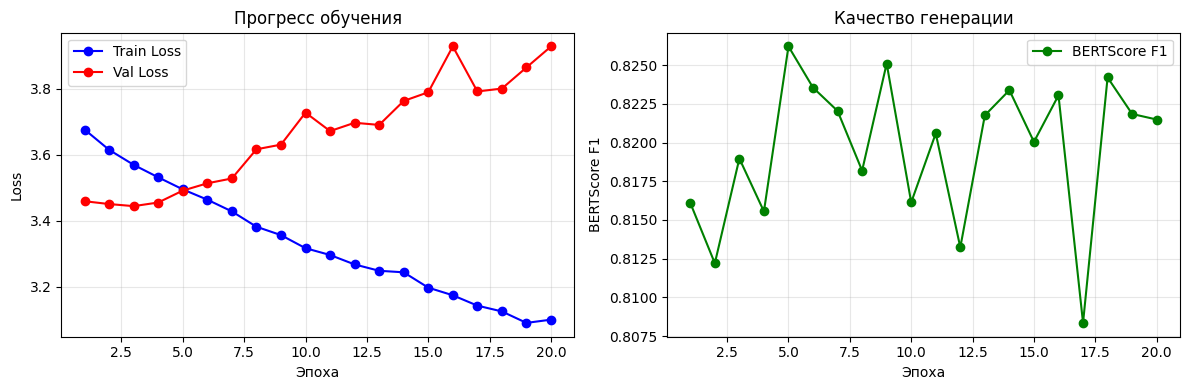

In [ ]:
# Создаем новый trainer для чистого прогона на урезанном датасете
test_trainer = QwenAudioDescriptionTrainer(
    qwen_model=qwen_model,
    qwen_tokenizer=qwen_tokenizer,
    audio_encoder=audio_encoder,
    audio_adapter=audio_adapter,
    device=device,
    lr=1e-4
)

test_evaluator = AudioDescriptionEvaluator(test_trainer, device)

results = train_and_evaluate(
    test_trainer,
    test_evaluator,
    small_train,
    small_val,
    num_epochs=20
)

In [ ]:
print(f"  Final Train Loss: {results['train_losses'][-1]:.4f}")
print(f"  Final Val Loss: {results['val_losses'][-1]:.4f}")
print(f"  Final BERTScore F1: {results['bert_scores'][-1]:.4f}")

  Final Train Loss: 3.1009
  Final Val Loss: 3.9275
  Final BERTScore F1: 0.8215


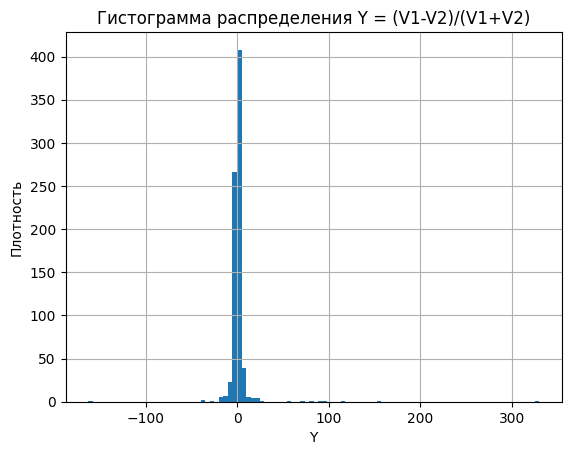

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 10**3

# Генерация равномерно в круге методом отбраковки
x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)
inside = x**2 + y**2 <= 1
x = x[inside]
y = y[inside]
# урезаем до одинакового количества или перегенерируем
# но для простоты оставим как есть (стало меньше n)
V1 = x
V2 = y

Y = (V1 - V2) / (V1 + V2)
# избегаем деления на ноль:
mask = np.abs(V1 + V2) > 1e-12
Y = Y[mask]

plt.hist(Y, bins=100, density=True)
plt.xlabel('Y')
plt.ylabel('Плотность')
plt.title('Гистограмма распределения Y = (V1-V2)/(V1+V2)')
plt.grid(True)
plt.show()